#### gaia_guery_activity_updated_dr3_v6


## How to Query and Plot data from the Gaia Sattelite Database?</h1>

Here are some useful links 
- [European Space Agency Gaia Mission - Writing Queries Turorial](https://www.cosmos.esa.int/web/gaia-users/archive/writing-queries)
- [Gaia's Hertzsprung-Russel Diagram](https://sci.esa.int/web/gaia/-/60198-gaia-hertzsprung-russell-diagram)
- [HRD with Milky Way Stars](HRD_with_milky_way_stars.png)
- [Color Index](https://en.wikipedia.org/wiki/Color_index)
- [Astronomical Data in Python](https://allendowney.github.io/AstronomicalData/README.html)

In the examples below we will query ***half-a-million stars within 200 Parsecs of the sun and plot it in a Hertzsprung-Russel Diagram (HRD)***


In [ ]:
#!echo $PATH  # for debugging as needed

In [ ]:
# Data Folder
data_folder="data_folder"
!ls -l {data_folder}

In [ ]:
#!pip list  # for debugging as needed

In [ ]:
#EXECUTE THIS CELL THEN RESTART KERNEL
#!pip install astroquery  # for debugging as needed

In [1]:
# Create Access to the Gaia Database
from astroquery.gaia import Gaia

# Load Tables from the Gai Database
tables = Gaia.load_tables(only_names=True)

# Print the Table Names in the Gaia Database
for table in tables:
    print(table.name)

The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive
INFO: Retrieving tables... [astroquery.utils.tap.core]
INFO: Parsing tables... [astroquery.utils.tap.core]
INFO: Done. [astroquery.utils.tap.core]
external.apassdr9
external.catwise2020
external.gaiadr2_astrophysical_parameters
external.gaiadr2_geometric_distance
external.gaiaedr3_distance
external.gaiaedr3_gcns_main_1
external.gaiaedr3_gcns_rejected_1
external.gaiaedr3_spurious
external.gaia_eso_survey
external.galex_ais
external.lamost_dr9_lrs
external.lamost_dr9_mrs
external.ravedr5_com
external.ravedr5_dr5
external.ravedr5_gra
exter

In [2]:
# Get Gaia Sources Table
meta = Gaia.load_table('gaiadr3.gaia_source')
print(meta)

TAP Table name: gaiadr3.gaia_source
Description: This table has an entry for every Gaia observed source as published with this data release. It contains the basic source parameters, in their final state as processed by the Gaia Data Processing and Analysis Consortium from the raw data coming from the spacecraft. The table is complemented with others containing information specific to certain kinds of objects (e.g.~Solar--system objects, non--single stars, variables etc.) and value--added processing (e.g.~astrophysical parameters etc.). Further array data types (spectra, epoch measurements) are presented separately via Datalink resources.
Size (bytes): 3646930329600
Num. columns: 152


In [3]:
# Print all columns in the Gaia Source Table
for column in meta.columns:
    print(column.name)

solution_id
designation
source_id
random_index
ref_epoch
ra
ra_error
dec
dec_error
parallax
parallax_error
parallax_over_error
pm
pmra
pmra_error
pmdec
pmdec_error
ra_dec_corr
ra_parallax_corr
ra_pmra_corr
ra_pmdec_corr
dec_parallax_corr
dec_pmra_corr
dec_pmdec_corr
parallax_pmra_corr
parallax_pmdec_corr
pmra_pmdec_corr
astrometric_n_obs_al
astrometric_n_obs_ac
astrometric_n_good_obs_al
astrometric_n_bad_obs_al
astrometric_gof_al
astrometric_chi2_al
astrometric_excess_noise
astrometric_excess_noise_sig
astrometric_params_solved
astrometric_primary_flag
nu_eff_used_in_astrometry
pseudocolour
pseudocolour_error
ra_pseudocolour_corr
dec_pseudocolour_corr
parallax_pseudocolour_corr
pmra_pseudocolour_corr
pmdec_pseudocolour_corr
astrometric_matched_transits
visibility_periods_used
astrometric_sigma5d_max
matched_transits
new_matched_transits
matched_transits_removed
ipd_gof_harmonic_amplitude
ipd_gof_harmonic_phase
ipd_frac_multi_peak
ipd_frac_odd_win
ruwe
scan_direction_strength_k1
scan_di

In [4]:
# Create a Synchronous (immediate submit) Query Job 
# for just the top 10 rows from the table retrieving
# columns source_id, ra, dec, parallax (How did I know the column names ??)
# note that it validates and gives you the units, description and bad rows!
query1 = """SELECT 
TOP 10
source_id, ra, dec, parallax 
FROM gaiadr3.gaia_source
"""
job1 = Gaia.launch_job(query1)
job1
print(job1)

<Table length=10>
   name    dtype  unit                            description                             n_bad
--------- ------- ---- ------------------------------------------------------------------ -----
source_id   int64      Unique source identifier (unique within a particular Data Release)     0
       ra float64  deg                                                    Right ascension     0
      dec float64  deg                                                        Declination     0
 parallax float64  mas                                                           Parallax     3
Jobid: None
Phase: COMPLETED
Owner: None
Output file: a0efa098-3231-11f1-9054-bc97e148b76b-O-result.vot.gz
Results: None


In [5]:
print(query1)

SELECT 
TOP 10
source_id, ra, dec, parallax 
FROM gaiadr3.gaia_source



In [6]:
# This statement below retrieves the result (note only 10 rows retrieved because that is what we asked for!)
results = job1.get_results()
results

source_id,ra,dec,parallax
,deg,deg,mas
int64,float64,float64,float64
1340029955712,44.96907662980059,0.08442520281043711,0.41561559118591507
5050881701504,44.95293834446748,0.13389088654489384,2.835755592946637
9689446227072,45.18244129477866,0.218552498227712,1.4964345376613277
9998684035328,45.134505293756575,0.21945053756369917,0.3437710922402742
15564962102784,45.2174185600749,0.33336146499770897,1.34818547544596
16870631995648,45.11522803653889,0.3827522965828968,1.4638534119564361
18180597405824,44.88836447627851,0.20588680921384442,--
18455474776704,44.85859130986471,0.21724190698216267,-1.2998443199388727


In [9]:
# Create a Asynchronous (scheduled submit) Query Job
# for just the top 2000 rows from the table retrieving
# columns source_id, ra, dec, pmra, pmdec, parallax, bp_rp 
# with a WHERE clause
# note that it validates and gives you the units, description and bad rows!
# What does Parallax < 1 mean in terms of distance ??  d = 1/p
query2 = """SELECT 
TOP 2000
source_id, ra, dec, pmra, pmdec, parallax, phot_g_mean_mag, 1000/parallax as dist, bp_rp
FROM gaiadr3.gaia_source
WHERE 1000/parallax < 200 and 1000/parallax > 150
"""
job2 = Gaia.launch_job_async(query2)
print(job2)

INFO: Query finished. [astroquery.utils.tap.core]
<Table length=2000>
      name       dtype    unit                              description                             n_bad
--------------- ------- -------- ------------------------------------------------------------------ -----
      source_id   int64          Unique source identifier (unique within a particular Data Release)     0
             ra float64      deg                                                    Right ascension     0
            dec float64      deg                                                        Declination     0
           pmra float64 mas / yr                         Proper motion in right ascension direction     0
          pmdec float64 mas / yr                             Proper motion in declination direction     0
       parallax float64      mas                                                           Parallax     0
phot_g_mean_mag float32      mag                                              G-ba

In [10]:
# This statement below retrieves the result (note 2000 rows retrieved because that is what we asked for!)
results = job2.get_results()
results

source_id,ra,dec,pmra,pmdec,parallax,phot_g_mean_mag,dist,bp_rp
,deg,deg,mas / yr,mas / yr,mas,mag,,mag
int64,float64,float64,float64,float64,float64,float32,float64,float32
11510512362368,45.25564613280313,0.29032307912696464,-42.18655907409065,-57.68607630889964,6.119356354805919,17.598793,163.41587938650386,3.1187668
23300197765248,44.70822577833431,0.29959791419118204,62.800134456058785,-36.92461323848409,5.1916784256930155,18.547283,192.61593612021804,2.6934147
115036404600448,45.239085969393926,0.808044951023683,29.12930094763781,-9.263493333089732,5.3652672818786495,18.64139,186.38400427459223,3.5720234
130193344404096,44.83607541127354,0.9525287003721735,48.68302811334293,-8.624683972234424,5.913201945575596,15.039726,169.11311489170848,2.309699
132667245587072,45.0727955724553,0.969970782487376,29.432375835260864,-93.78045808765805,5.737753870967776,7.4750457,174.28422732802443,1.2528615
288175125714560,44.287428493193936,0.7743463085708776,-18.37357125886843,-18.706614397964973,6.519816873090421,17.467531,153.3785410641443,-0.02720642
406888023788928,44.20141176303378,1.4322037943473536,3.054857842925146,-6.149966457198046,5.196300795139288,20.669888,192.4445946115009,1.4475555
619780960797696,46.68847219566565,1.8270147658417926,-3.561345139825287,-13.474774725266128,5.603567525252307,17.910654,178.45774062568717,3.0923252


In [ ]:
print(results["parallax"], results["phot_g_mean_mag"],results["bp_rp"])

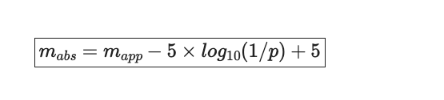

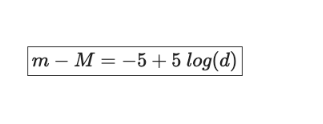

In [16]:
# Calculate absolute magnitude with parallax in mas
# Make sure parallax > 0 by creating another filter

import numpy as np # for log10() function

distance_modulus = -5 * np.log10(results['parallax']) + 10
abs_mag_alt = results['phot_g_mean_mag'] - distance_modulus

abs_mag = results["phot_g_mean_mag"] -5*np.log10(1000/results["parallax"])+5

bp_rp = results['bp_rp']

#print(bp_rp)
print(abs_mag_alt)
print(abs_mag)

 phot_g_mean_mag  
------------------
11.532321753048583
12.123822094003321
12.289346657392318
 8.898839812941677
1.2687552541805793
11.538708191991185
 14.24835895708536
 11.65297711661843
 10.90622463876564
 4.499027769861106
               ...
11.457001157576276
10.694981728112896
 3.525360929890442
 9.983984506156794
10.104476483695624
  12.4619072184536
 6.830180144497621
11.106699016087969
 6.521439006911525
 8.166634142231144
Length = 2000 rows
 phot_g_mean_mag  
------------------
11.532321753048583
12.123822094003321
12.289346657392318
 8.898839812941675
1.2687552541805793
11.538708191991185
 14.24835895708536
 11.65297711661843
 10.90622463876564
 4.499027769861106
               ...
11.457001157576276
10.694981728112896
 3.525360929890443
 9.983984506156792
10.104476483695626
12.461907218453602
 6.830180144497621
11.106699016087969
 6.521439006911525
 8.166634142231144
Length = 2000 rows


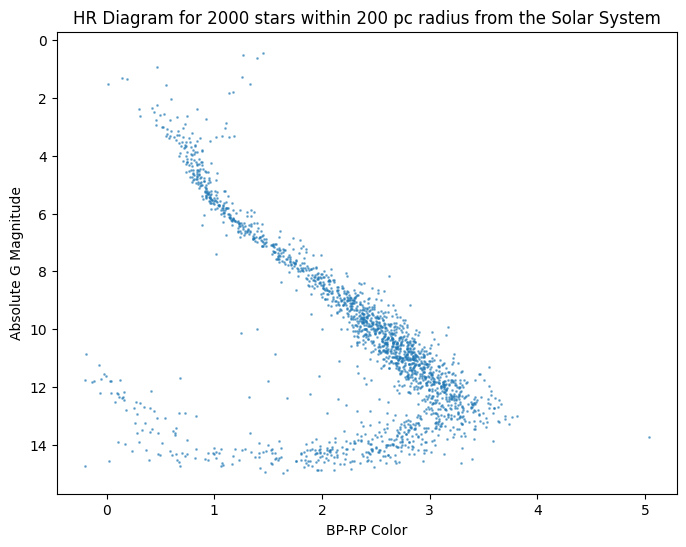

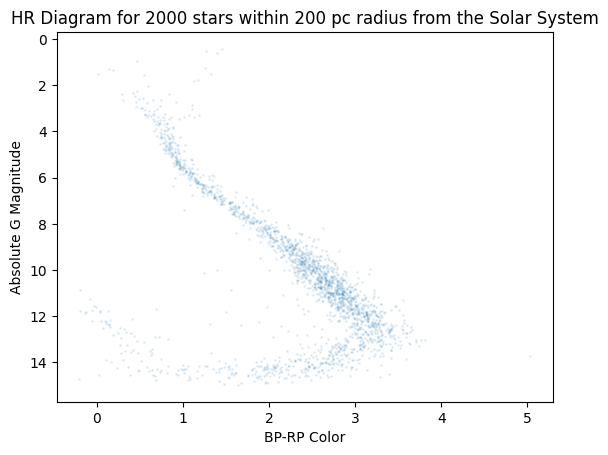

In [19]:
# plot the H-R diagram for the 2000 stars within 200 pc radius from the Solar System
%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(bp_rp, abs_mag, s=1, alpha=0.5)
plt.gca().invert_yaxis()
plt.xlabel("BP-RP Color")
plt.ylabel("Absolute G Magnitude")
plt.title(f"HR Diagram for 2000 stars within 200 pc radius from the Solar System")
plt.show()
plt.scatter(bp_rp, abs_mag_alt, s=1, alpha=0.1)
plt.gca().invert_yaxis()
plt.xlabel("BP-RP Color")
plt.ylabel("Absolute G Magnitude")
plt.title(f"HR Diagram for 2000 stars within 200 pc radius from the Solar System")
plt.show()

In [20]:
# Here I am defining a python function to execute a asynchronous query which I can then pass to a Job
def send_radial_gaia_query(query_size=500, distance=200, **kwargs):
    """
    Sends an archive query for d < 200 pc, with additional filters taken from
    Gaia Data Release 3: Observational Hertzsprung-Russell diagrams (Sect. 2.1)
    Gaia Collaboration, Babusiaux et al. (2018)
    (https://doi.org/10.1051/0004-6361/201832843)

    NOTE: 10000000 is a maximum query size (~76 MB / column)

    Additional keyword arguments are passed to Gaia.launch_job_async method.
    """
    query3 = (" SELECT"
            " TOP {}".format(query_size)+
            " source_id, ra, dec, parallax, bp_rp, phot_g_mean_mag+5*log10(parallax)-10 as mg, 1000/parallax as dist"
            " FROM gaiadr3.gaia_source"
            " WHERE parallax > 0"
            " AND bp_rp > -0.75"
            " AND bp_rp < 6"
            " AND 1000/parallax <= {}".format(distance)+
            " AND bp_rp > -0.75"
            " AND bp_rp < 6"
            " AND visibility_periods_used > 8"
            " AND phot_g_mean_flux_over_error > 50"
            " AND phot_bp_mean_flux_over_error > 20"
            " AND phot_rp_mean_flux_over_error > 20"  
            " and phot_bp_rp_excess_factor <"
            " 1.3+0.06*power(phot_bp_mean_mag-phot_rp_mean_mag,2)"
            " and phot_bp_rp_excess_factor >"
            " 1.0+0.015*power(phot_bp_mean_mag-phot_rp_mean_mag,2)"
            " and astrometric_chi2_al/(astrometric_n_good_obs_al-5)<"
            "1.44*greatest(1,exp(-0.4*(phot_g_mean_mag-19.5)))"   
    )


    
    job = Gaia.launch_job_async(query3, **kwargs)
    return job

In [22]:
job3 = send_radial_gaia_query(query_size=8000,distance=100)  # Query 10000 alhough default is 500 stars
results = job3.get_results()
results

INFO: Query finished. [astroquery.utils.tap.core]


source_id,ra,dec,parallax,bp_rp,mg,dist
,deg,deg,mas,mag,,
int64,float64,float64,float64,float32,float64,float64
92603790642688,44.41500318632742,0.5679005443548504,10.969874447270998,0.90176105,5.121641601056062,91.15874614670476
1611029348487680,43.92070343473486,3.0634098423356084,11.831171660416297,2.549201,9.783121833392485,84.52248253194676
1880233603259648,46.22758701741421,3.600073193340884,14.90199885781868,0.38295937,13.194881686489957,67.10509170891036
1883673872488960,45.84266942155914,3.5143529954614148,14.462367167453491,3.3867588,12.961427552158238,69.14497387747336
2021898804878976,44.878638787583654,3.682874199298614,14.04087378543737,0.8228245,14.212810292151111,71.22063877799114
4691208094573312,43.56929231456171,3.570775539289296,13.780113518176917,2.5915318,10.353632636116654,72.56834268316668
4796074015983360,41.74829426882626,3.2124692422958914,17.349804031770535,2.4385986,10.095129713810422,57.6375386239997
4984189288211840,42.22326648193585,4.17273700471477,17.58501923215187,3.4057226,12.999975712742781,56.866585517952295


In [23]:
mg = results["mg"]
bp_rp = results["bp_rp"]

In [30]:
# sun's HRD coordinates values for plotting
#     google "what is bp-rp of the sun" bp-rp = 0.82
bp_rp_sun = 0.82

#     we calculated the abs mag of the sun in the "brightness of stars" project
#     we will do it again below:
sun_app_mag = -27.5 # very very bright in the sky!
sun_dist_km = 150e6 #km
light_speed = 3e5 #km/s
seconds_in_a_year = 365*24*3600  # s/yr
light_year_km =  light_speed * seconds_in_a_year # s/ly
parsec_km = light_year_km * 3.27 #km/pc
sun_dist_pc = sun_dist_km / parsec_km

# Use the magnitude formula above to calculate the absolute magnitude of the Sun
sun_abs_mag = sun_app_mag - 5*np.log10(sun_dist_pc) +5
print(sun_abs_mag)

4.071921776298176


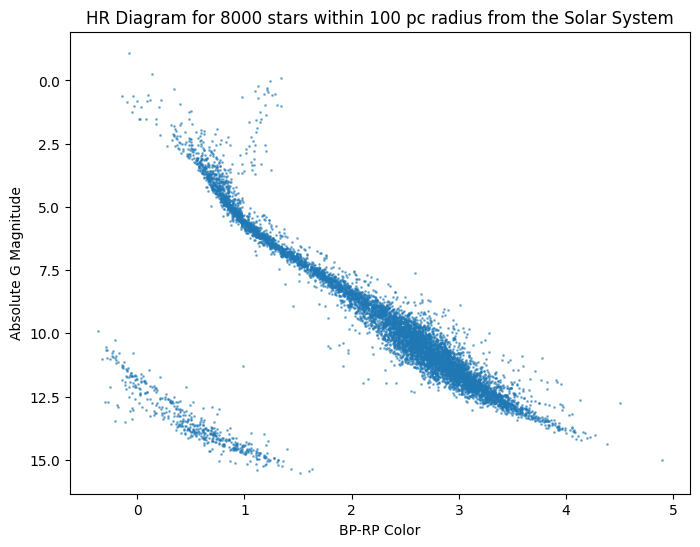

In [31]:
# plot the H-R diagram for the 10000 stars within 200 pc radius from the Solar System
%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(bp_rp, mg, s=1, alpha=0.5)
plt.gca().invert_yaxis()
plt.xlabel("BP-RP Color")
plt.ylabel("Absolute G Magnitude")
plt.title(f"HR Diagram for 8000 stars within 100 pc radius from the Solar System")
plt.show()

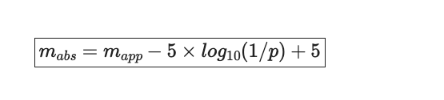

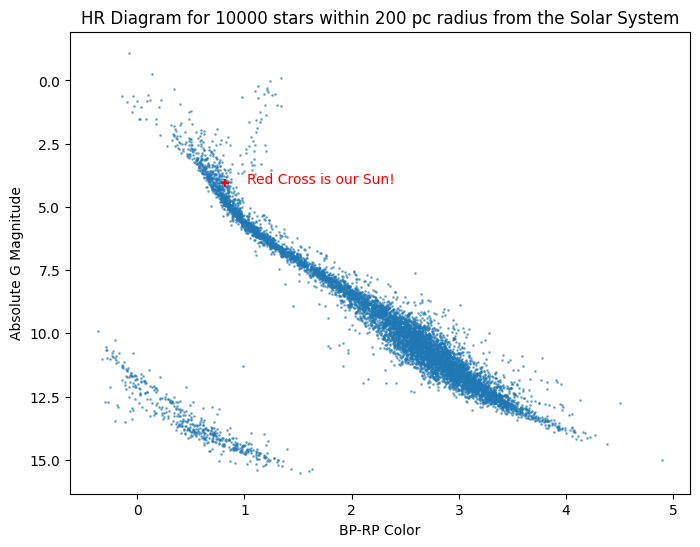

In [32]:
# plot the H-R diagram for the 10000 stars within 200 pc radius from the Solar System
# Also plot the Sun using the plt.scatter() method!
%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(bp_rp, mg, s=1, alpha=0.5) # Plot the HRD

plt.scatter(bp_rp_sun, sun_abs_mag, marker='+', color="red") # plot a single cross for the sun
plt.text(bp_rp_sun+0.2, sun_abs_mag, "Red Cross is our Sun!",  color="red")

plt.gca().invert_yaxis()
plt.xlabel("BP-RP Color")
plt.ylabel("Absolute G Magnitude")
plt.title(f"HR Diagram for 10000 stars within 200 pc radius from the Solar System")
plt.show()

In [45]:
!ls -l data_folder
small_datafile_name = f"data_folder/gaia-hrd-dr3-200pc_{num_stars}_stars.csv"
!ls -l small_datafile_name

total 13268
drwxr-xr-x 2 jupyter-boyceastro jupyter-boyceastro     4096 Feb 13  2025 archive
-rw-r--r-- 1 jupyter-boyceastro jupyter-boyceastro 12028406 Mar 31 02:47 gaia-hrd-dr3-200pc_100000_stars.csv
-rw-r--r-- 1 jupyter-boyceastro jupyter-boyceastro  1195390 Mar 31 02:46 gaia-hrd-dr3-200pc_10000_stars.csv
-rw-r--r-- 1 jupyter-boyceastro jupyter-boyceastro   354729 Mar 31 02:51 gaia-hrd-dr3-200pc_10000_stars.csv.png
ls: cannot access 'small_datafile_name': No such file or directory


In [51]:
# Here I am defining a job for the same asynchronous within a try-except block
# This will first look for a previoysly stored file (try-block)
# if it does not exist it will execute the query (except-bloclk)

import numpy as np
from astropy import log

num_stars = 100000
small_datafile_name = f"data_folder/gaia-hrd-dr3-200pc_{num_stars}_stars.csv"
try:
    log.info(f"Getting the DR3 results on nearby (d < 200 pc) stars stored in {small_datafile_name}\n")
    #gaiarec = np.recfromcsv(small_datafile_name)
    gaiarec = np.genfromtxt(small_datafile_name, delimiter=',', names=True, dtype=None)
    #bp_rp, mg, dist = gaiarec.bp_rp, gaiarec.mg, gaiarec.dist
    bp_rp, mg, dist = gaiarec["bp_rp"], gaiarec["mg"], gaiarec["dist"]
    print(f"reading OLD results from previously existng {small_datafile_name}\n")
    print(bp_rp, mg, dist)
except OSError:
    job4 = send_radial_gaia_query(dump_to_file=True, output_format="csv",
                                 output_file=small_datafile_name,
                                 query_size=num_stars,distance=200)
    results = job4.get_results()
    bp_rp = results['bp_rp'].data
    mg = results['mg'].data
    dist = results['dist'].data
    print(f"querying and saving NEW results to {small_datafile_name}\n")
    print(bp_rp, mg, dist)


INFO: Getting the DR3 results on nearby (d < 200 pc) stars stored in data_folder/gaia-hrd-dr3-200pc_50000_stars.csv
 [unknown]
querying and saving NEW results to data_folder/gaia-hrd-dr3-200pc_50000_stars.csv

[3.1187668 2.5765915 2.309699  ... 2.723548  2.1265516 2.873458 ] [11.53232175  9.96826866  8.89883981 ... 10.86747316  8.69143722
 10.2639286 ] [163.41587939  65.67350535 169.11311489 ... 107.18205573 120.00747121
 133.26150232]


#### Find the CSV file and double-click it!
#### Once you have done this - go back to the previous Cell and execute once more and see what happens!!
#### Can you describe what happened ??
#### Now let's plot it!!

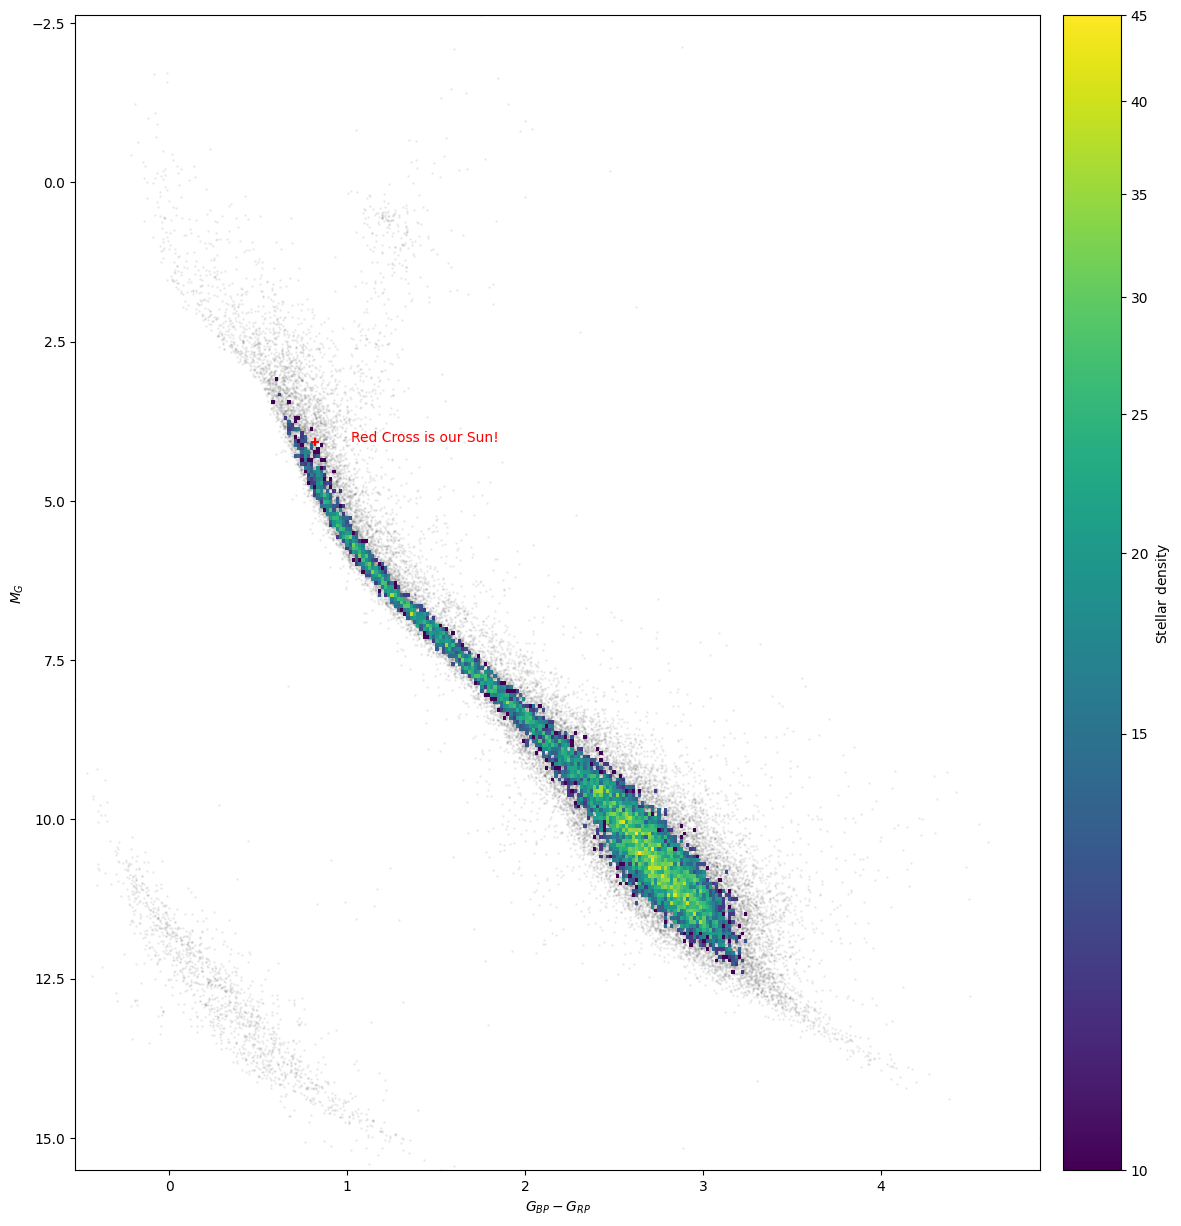

In [54]:
# plot the H-R diagram for the 10000 stars within 200 pc from the Sun
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import colors
plt.rc('text', usetex=False)

fig, ax = plt.subplots(figsize=(15, 15))
# only show 2D-histogram for bins with more than 10 stars in them
h = ax.hist2d(bp_rp, mg, bins=300, cmin=10, norm=colors.PowerNorm(0.5), zorder=0.5)
# fill the rest with scatter (set rasterized=True if saving as vector graphics)
ax.scatter(bp_rp, mg, alpha=0.05, s=1, color='k', zorder=0)

ax.scatter(bp_rp_sun, sun_abs_mag, marker='+', color="red") # plot a single cross for the sun
ax.text(bp_rp_sun+0.2, sun_abs_mag, "Red Cross is our Sun!",  color="red")

ax.invert_yaxis()
cb = fig.colorbar(h[3], ax=ax, pad=0.02)
ax.set_xlabel(r'$G_{BP} - G_{RP}$')
ax.set_ylabel(r'$M_G$')
cb.set_label(r"$\mathrm{Stellar~density}$")
plt.savefig(f"{small_datafile_name}.png", dpi=140)

In [ ]:
# plot the H-R diagram for the 10000 stars within 200 pc from the Sun
# this time add our Sun to the plot!!

# YOUR CODE GOES HERE!!
# plot the H-R diagram for the 10000 stars within 200 pc from the Sun
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import colors
plt.rc('text', usetex=False)

fig, ax = plt.subplots(figsize=(15, 15))
# only show 2D-histogram for bins with more than 10 stars in them
h = ax.hist2d(bp_rp, mg, bins=300, cmin=10, norm=colors.PowerNorm(0.5), zorder=0.5)
# fill the rest with scatter (set rasterized=True if saving as vector graphics)
ax.scatter(bp_rp, mg, alpha=0.05, s=1, color='k', zorder=0)
ax.invert_yaxis()
cb = fig.colorbar(h[3], ax=ax, pad=0.02)
ax.set_xlabel(r'$G_{BP} - G_{RP}$')
ax.set_ylabel(r'$M_G$')
cb.set_label(r"$\mathrm{Stellar~density}$")
plt.savefig(f"{small_datafile_name}.png", dpi=140)

In [ ]:
# Here I am defining a new with filters job for the same asynchronous within the try-except block
# This time for 100000 stars now including the filters
# This will first look for a reviosly stored file (try-block)
# if it does not exist it will execute the query (except-block)
import numpy as np
from astropy import log

# the query runs for a while, better ensure we have those data saved
num_stars = 100000
large_datafile_name = data_folder+"/gaia-hrd-dr3-200pc_%d_stars.csv" % (num_stars)
try:
    log.info(f"Getting the DR3 results on nearby (d < 200 pc) stars stored in {large_datafile_name}\n")
    #gaiarec = np.recfromcsv(large_datafile_name)
    gaiarec = np.genfromtxt(large_datafile_name, delimiter=',', names=True, dtype=None)
    #bp_rp, mg, dist = gaiarec.bp_rp, gaiarec.mg, gaiarec.dist
    bp_rp, mg, dist = gaiarec["bp_rp"], gaiarec["mg"], gaiarec["dist"]
    print(f"reading OLD results from previously existng {large_datafile_name}\n")
    print(bp_rp, mg, dist)    
except OSError:
    job = send_radial_gaia_query(dump_to_file=True, output_format="csv"
                                 ,output_file=large_datafile_name
                                 ,query_size=num_stars
    )
    r = job.get_results()
    bp_rp = r['bp_rp'].data
    mg = r['mg'].data
    dist = r['dist'].data
    print(f"querying and saving NEW results to {large_datafile_name}\n")
    print(bp_rp, mg, dist)

In [ ]:
!ls -ltr {data_folder}

In [ ]:
# plot the H-R diagram for the 10000 stars within 200 pc from the Sun
# write code below to plot the HRD!!
# ADD Sun, Algenib, Rigel, Deneb, Vega, Betelgeuse, Polaris, Aldebaran, 
# Barnard's Star, Arcturus, Pollux, Mirach, Mira, Sirius B, Gliese 229B,
# SDSS J0104+1535, ZTF J2020+5033, HD 984 B


# YOUR CODE GOES HERE!!